# Chapter 08 답안 양식. 작은 데이터 분석 프로젝트 완성하기

### 제출 정보
- 이름: 전예진
- GitHub ID:wjs0951467-wq
- 작성일:2027-09-17
- 최종 Notebook URL:https://github.com/wjs0951467-wq/llm-data-analysis-study/blob/main/chapter08/chapter08.ipynb

## 1. 프로젝트 질문

### 분석 질문
1. 카테고리별 completed 주문 기준 금액은 어떻게 다른가?
2. 월별 completed 주문 기준 금액과 주문 수는 어떻게 변하는가?
3. completed 주문 기준 고객별 구매 금액은 어떻게 다른가?

### 분석 범위
- 금액성 분석은 `order_status == "completed"`인 주문만 사용한다.
- 주문 상태 분포를 확인할 때는 전체 주문 데이터를 사용한다.
- 원본 데이터는 `data/raw`의 4개 CSV 파일을 사용한다.

### 사용할 데이터와 지표
- 사용 데이터:
  - `customers.csv`
  - `products.csv`
  - `orders.csv`
  - `order_items.csv`

- 주요 지표:
  - 카테고리별 `total_sales`
  - 월별 `total_sales`
  - 월별 `order_count`
  - 고객별 `total_sales`
  - 고객별 `order_count`

### 계산 기준
- `order_status == "completed"` 적용 여부: 적용
- `line_total = quantity × unit_price` 확인 여부: 후속 검증 단계에서 확인

### 완료 기준
- PK 결측과 중복이 0건인지 확인한다.
- FK 미매칭이 0건인지 확인한다.
- 병합 후 행 수와 미매칭 여부를 확인한다.
- `line_total = quantity × unit_price`가 일치하는지 확인한다.
- category / month / customer 총합이 completed source total과 일치하면 완료로 판단한다.
- 최종 Validation 항목이 모두 PASS인지 확인한다.

In [42]:
from pathlib import Path

print("현재 위치:", Path.cwd())
print("상위 폴더:", Path.cwd().parent)

현재 위치: c:\dev\llm-data-analysis-study\chapter08
상위 폴더: c:\dev\llm-data-analysis-study


In [43]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트 폴더를 찾을 수 없습니다.")


PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

for path in [PROCESSED_DIR, REPORT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python 실행 파일:", sys.executable)
print("프로젝트 루트:", PROJECT_ROOT)
print("원본 데이터 폴더:", RAW_DIR)
print("보고서 폴더:", REPORT_DIR)

Python 실행 파일: c:\dev\llm-data-analysis-study\.venv\Scripts\python.exe
프로젝트 루트: c:\dev\llm-data-analysis-study
원본 데이터 폴더: c:\dev\llm-data-analysis-study\data\raw
보고서 폴더: c:\dev\llm-data-analysis-study\reports


In [44]:
from src.data_loader import load_sales_data
from src.preprocessing import (
    compare_shapes,
    preprocess_sales_data,
    save_processed_data,
    validate_relationships,
)
from src.midterm_project import (
    FORBIDDEN_CUSTOMER_COLUMNS,
    build_analysis_tables,
    build_interpretation_notes,
    build_key_duplicate_checks,
    build_midterm_report,
    build_project_validation,
    create_project_figures,
    run_midterm_project,
    save_project_tables,
    summarize_datasets,
)

In [45]:
raw_data = load_sales_data(RAW_DIR)

dataset_summary = summarize_datasets(raw_data)
display(dataset_summary)

for name, df in raw_data.items():
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing values:", int(df.isna().sum().sum()))
    print("duplicated rows:", int(df.duplicated().sum()))

,dataset,rows,columns,missing_values,duplicated_rows
0,customers,150,6,0,0
1,products,100,4,0,0
2,orders,300,5,0,0
3,order_items,764,5,0,0



===== customers =====
shape: (150, 6)
columns: ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
missing values: 0
duplicated rows: 0

===== products =====
shape: (100, 4)
columns: ['product_id', 'product_name', 'category', 'price']
missing values: 0
duplicated rows: 0

===== orders =====
shape: (300, 5)
columns: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
missing values: 0
duplicated rows: 0

===== order_items =====
shape: (764, 5)
columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']
missing values: 0
duplicated rows: 0


In [46]:
processed_data = preprocess_sales_data(raw_data)
processed_paths = save_processed_data(processed_data, PROCESSED_DIR)

preprocessing_comparison = compare_shapes(raw_data, processed_data)
display(preprocessing_comparison)

for path in processed_paths:
    print(path, "OK" if path.exists() else "MISSING")

,dataset,rows_raw,columns_raw,rows_processed,columns_processed
0,customers,150,6,150,6
1,order_items,764,5,764,6
2,orders,300,5,300,7
3,products,100,4,100,4


c:\dev\llm-data-analysis-study\data\processed\customers_clean.csv OK
c:\dev\llm-data-analysis-study\data\processed\products_clean.csv OK
c:\dev\llm-data-analysis-study\data\processed\orders_clean.csv OK
c:\dev\llm-data-analysis-study\data\processed\order_items_clean.csv OK


## 2. 입력 데이터와 전처리 검증

- 사용 원본 파일:
  - `customers.csv`
  - `products.csv`
  - `orders.csv`
  - `order_items.csv`

- shape:
  - customers: 150행, 6열
  - products: 100행, 4열
  - orders: 300행, 5열
  - order_items: 764행, 5열

- 핵심 결측/중복 결과:
  - 4개 데이터셋 모두 결측값 0건
  - 4개 데이터셋 모두 전체 행 중복 0건

- 전처리 전후 변화:
  - customers: 150행 → 150행
  - products: 100행 → 100행
  - orders: 300행 → 300행
  - order_items: 764행 → 764행
  - 전처리 후 행 수는 모두 유지되었다.
  - 일부 데이터셋은 전처리 과정에서 컬럼이 추가되었다.

![입력 데이터 검증](images/step02_data_validation.png)

### 나의 해석과 판단

원본 데이터에서 결측값과 전체 행 중복이 발견되지 않았고,
전처리 후에도 모든 데이터셋의 행 수가 유지된 것을 확인했다.
따라서 전처리 과정에서 데이터가 임의로 삭제되거나 증가한 문제는 없는 것으로 판단했다.

### 한계와 추가 확인 사항

전체 행 중복이 0건이라고 해서 주요 ID 컬럼의 중복까지 없다고 단정할 수는 없다.
따라서 다음 단계에서 PK와 FK를 별도로 검증해야 한다.

In [47]:
key_duplicate_checks = build_key_duplicate_checks(processed_data)
relationship_checks = validate_relationships(processed_data).copy()

if not relationship_checks.empty:
    relationship_checks["status"] = (
        relationship_checks["invalid_count"]
        .eq(0)
        .map({True: "PASS", False: "FAIL"})
    )

display(key_duplicate_checks)
display(relationship_checks)

assert key_duplicate_checks["status"].eq("PASS").all(), "PK Validation 실패"
assert (
    not relationship_checks.empty
    and relationship_checks["invalid_count"].eq(0).all()
), "FK Validation 실패"

print("PK/FK Gate: PASS")

,dataset,key,missing_count,duplicate_count,status,detail
0,customers,customer_id,0,0,PASS,
1,products,product_id,0,0,PASS,
2,orders,order_id,0,0,PASS,
3,order_items,order_item_id,0,0,PASS,


,check,invalid_count,status
0,orders.customer_id exists in customers.custome...,0,PASS
1,order_items.order_id exists in orders.order_id,0,PASS
2,order_items.product_id exists in products.prod...,0,PASS


PK/FK Gate: PASS


## 3. PK/FK·병합 검증

### PK 결과
- 결측: 0건
- 중복: 0건
- PASS/FAIL: PASS

### FK 결과
- 미매칭: 0건
- PASS/FAIL: PASS

### 나의 해석과 판단

주요 PK인 `customer_id`, `product_id`, `order_id`, `order_item_id`에서
결측과 중복이 모두 0건으로 확인되었다.

또한 주요 FK 관계에서도 부모 테이블에 존재하지 않는 참조값이 발견되지 않았다.
따라서 현재 데이터의 기본 키와 참조 관계는 후속 병합을 진행할 수 있는 상태라고 판단했다.

In [48]:
analysis_tables = build_analysis_tables(processed_data)

display(analysis_tables["merge_checks"])
display(analysis_tables["line_total_check"])
display(analysis_tables["date_checks"])
display(analysis_tables["amount_scope_summary"])

assert analysis_tables["merge_checks"]["status"].eq("PASS").all()
assert analysis_tables["line_total_check"]["status"].eq("PASS").all()

print("병합 / line_total Gate: PASS")

,merge,validate,before_rows,after_rows,row_count_preserved,unmatched_count,status
0,order_id → orders,many_to_one,764,764,True,0,PASS
1,product_id → products,many_to_one,474,474,True,0,PASS
2,customer_id → customers,one_to_one,100,100,True,0,PASS


,check,source,row_count,mismatch_count,status
0,line_total = quantity × unit_price,existing,764,0,PASS


,check,invalid_count,affected_amount,status
0,completed rows with invalid order_date,0,0.0,PASS


,scope,amount,detail_rows
0,all_order_items,255610000.0,764
1,completed_order_items,148990000.0,474
2,excluded_non_completed,106620000.0,290


병합 / line_total Gate: PASS


### 병합 결과
- validate 관계:
  - `order_id → orders`: many_to_one
  - `product_id → products`: many_to_one
  - `customer_id → customers`: one_to_one
- 병합 전 행 수:
  - order_id → orders: 764행
  - product_id → products: 474행
  - customer_id → customers: 100행
- 병합 후 행 수:
  - order_id → orders: 764행
  - product_id → products: 474행
  - customer_id → customers: 100행
- 미매칭: 0건
- PASS/FAIL: PASS

### 나의 해석과 판단

PK와 FK 검증 결과 모두 문제가 없었고, 병합에서도 예상한 관계가 정상적으로 적용되었다.
병합 전후 행 수가 동일하게 유지되어 병합으로 인해 행이 증가하거나 누락된 문제는 없는 것으로 판단했다.
또한 `line_total = quantity × unit_price` 관계를 764개 주문 상세 행에서 확인한 결과 불일치가 0건으로 나타났다.
따라서 이후 금액 분석에 `line_total`을 사용할 수 있다고 판단했다.

In [49]:
category_sales = analysis_tables["category_sales"]
monthly_sales = analysis_tables["monthly_sales"]
customer_sales_internal = analysis_tables["customer_sales"]
customer_sales_public = analysis_tables["customer_sales_public"]
order_status_summary = analysis_tables["order_status_summary"]

display(category_sales)
display(monthly_sales)
display(customer_sales_public.head(10))
display(order_status_summary)

print("내부 고객 결과 컬럼:", customer_sales_internal.columns.tolist())
print("공개 고객 결과 컬럼:", customer_sales_public.columns.tolist())

,category,total_quantity,total_sales,sales_ratio
0,스포츠,295,31743000,21.31
1,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
3,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
5,도서,149,16389000,11.00
6,패션,111,10587000,7.11


,order_month,total_sales,order_count,avg_order_value
0,2025-09,7190000,10,719000.0
1,2025-10,16291000,19,857421.0
2,2025-11,13704000,16,856500.0
3,2025-12,23360000,25,934400.0
4,2026-01,7282000,9,809111.0
5,2026-02,10851000,13,834692.0
6,2026-03,17538000,23,762522.0
7,2026-04,9589000,17,564059.0
8,2026-05,14798000,16,924875.0
9,2026-06,15402000,20,770100.0


,customer_label,city,order_count,total_sales,avg_order_value
0,Customer 01,성남,5,4100000,820000.0
1,Customer 02,고양,4,3996000,999000.0
2,Customer 03,수원,4,3880000,970000.0
3,Customer 04,서울,5,3590000,718000.0
4,Customer 05,서울,4,3523000,880750.0
5,Customer 06,인천,2,3191000,1595500.0
6,Customer 07,성남,2,3178000,1589000.0
7,Customer 08,광주,3,3153000,1051000.0
8,Customer 09,서울,4,3093000,773250.0
9,Customer 10,부산,2,2990000,1495000.0


,order_status,order_count,order_ratio
0,completed,184,61.33
1,cancelled,64,21.33
2,refunded,52,17.33


내부 고객 결과 컬럼: ['customer_id', 'customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
공개 고객 결과 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']


## 4. 핵심 EDA 결과

### 결과 1
- 수치/표:
  - 스포츠: 31,743,000원, 21.31%
  - 전자기기: 26,400,000원, 17.72%
  - 생활용품: 23,915,000원, 16.05%
  - 뷰티: 23,383,000원, 15.69%
  - 식품: 16,573,000원, 11.12%
  - 도서: 16,389,000원, 11.00%
  - 패션: 10,587,000원, 7.11%

- 결과 관찰:
  completed 주문 기준 금액은 스포츠 카테고리가 31,743,000원으로 가장 높았고,
  전체 completed 금액의 21.31%를 차지했다.
  패션 카테고리는 10,587,000원으로 가장 낮았다.

- 나의 해석과 판단:
  현재 completed 주문 금액에서 스포츠 카테고리의 비중이 상대적으로 큰 것을 확인했다.
  다만 금액이 높은 이유가 판매 수량 때문인지 상품 단가 때문인지는 현재 결과만으로 판단하기 어렵다.

- 업무·분석적 의미:
  금액 기여도가 높은 카테고리를 파악할 수 있으며,
  이후 판매 수량과 평균 단가를 함께 비교해 카테고리별 금액 차이의 원인을 추가로 분석할 수 있다.

- 한계:
  현재 결과는 completed 주문의 금액 합계만 비교한 것이므로 수익성이나 고객 선호도를 직접 의미하지는 않는다.


### 결과 2
- 수치/표:
  - 가장 높은 월별 금액: 2025-12, 23,360,000원, 주문 25건
  - 가장 낮은 월별 금액: 2026-08, 4,051,000원, 주문 5건

- 결과 관찰:
  2025년 12월의 completed 주문 기준 금액이 23,360,000원으로 가장 높았고,
  주문 수도 25건으로 가장 많았다.
  반대로 2026년 8월은 금액 4,051,000원, 주문 5건으로 가장 낮았다.

- 나의 해석과 판단:
  월별 completed 주문 금액과 주문 수가 일정하지 않고 변동하는 것을 확인했다.
  특히 2025년 12월은 다른 월보다 금액과 주문 수가 모두 높은 편이었다.

- 업무·분석적 의미:
  월별 주문 금액과 주문 수를 함께 확인하면 특정 시기의 주문 활동이 상대적으로 높거나 낮았는지 파악할 수 있다.
  이후 월별 상품 구성이나 고객 수 등의 추가 지표와 함께 비교할 필요가 있다.

- 한계:
  현재 데이터에는 광고, 행사, 계절 요인 등의 원인 정보가 없으므로
  특정 월의 금액 증가나 감소 원인을 단정할 수 없다.


### 결과 3
- 수치/표:
  - Customer 01: 4,100,000원, 5건
  - Customer 02: 3,996,000원, 4건
  - Customer 03: 3,880,000원, 4건

- 결과 관찰:
  completed 주문 기준 고객별 구매 금액은 Customer 01이 4,100,000원으로 가장 높았다.
  Customer 01의 completed 주문 수는 5건이었다.

- 나의 해석과 판단:
  일부 고객이 다른 고객보다 높은 completed 구매 금액을 보이는 것을 확인했다.
  고객별 구매 금액 차이가 존재하지만 상위 고객이라는 사실만으로 고객 충성도나 만족도를 판단할 수는 없다.

- 업무·분석적 의미:
  고객별 주문 수와 구매 금액을 함께 비교하면 반복 구매 고객이나 구매 금액이 큰 고객 집단을 확인하는 데 활용할 수 있다.

- 한계:
  현재 결과는 completed 주문의 구매 금액과 주문 수만 사용했으며,
  고객의 만족도, 구매 목적, 재구매 의도 등의 정보는 포함되어 있지 않다.

In [50]:
total_consistency = analysis_tables["total_consistency_check"]
display(total_consistency)

assert total_consistency["matches_completed"].all(), "Total consistency Gate 실패"
assert analysis_tables["date_checks"]["status"].eq("PASS").all(), "날짜 Gate 실패"

print("Total consistency / Date Gate: PASS")

,source,amount,difference_from_completed,matches_completed,status
0,completed_source,148990000.0,0.0,True,PASS
1,category,148990000.0,0.0,True,PASS
2,monthly,148990000.0,0.0,True,PASS
3,customer,148990000.0,0.0,True,PASS


Total consistency / Date Gate: PASS


## 5. Total consistency와 날짜 검증

- completed source total: 148,990,000원
- category total: 148,990,000원
- monthly total: 148,990,000원
- customer total: 148,990,000원
- 총합 일치 여부: 일치
- completed 주문 날짜 오류 건수: 0건
- 날짜 오류 영향 금액: 0원

### 불일치가 있었다면 원인

불일치는 없었다.
completed source, category, monthly, customer의 총합이 모두 148,990,000원으로 일치했다.
따라서 카테고리별, 월별, 고객별 집계가 동일한 completed 주문 범위에서 계산되었고,
병합이나 날짜 오류로 금액이 누락되거나 중복된 문제는 없는 것으로 판단했다.

In [51]:
forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(customer_sales_public.columns)
)
print("공개 결과 금지 컬럼:", forbidden)

assert not forbidden, "Privacy Gate 실패"
assert "customer_id" not in customer_sales_public.columns
print("Privacy Gate: PASS")

공개 결과 금지 컬럼: []
Privacy Gate: PASS


## 7. 개인정보 검증

- 공개 고객 CSV 컬럼:
  - `customer_label`
  - `city`
  - `order_count`
  - `total_sales`
  - `avg_order_value`

- 원본 `customer_id` 포함 여부: 미포함
- 이름/이메일/전화번호/주소 포함 여부: 미포함
- 익명 라벨 방식: `Customer 01`, `Customer 02` 형태의 순위 기반 익명 라벨 사용
- PASS/FAIL: PASS

### 나의 판단

공개 고객 결과에서 원본 `customer_id`와 이름, 이메일, 전화번호, 주소와 같은 직접 식별정보가 제거된 것을 확인했다.
또한 고객은 순위 기반 익명 라벨로 표시되어 있어 공개 결과에 불필요한 개인정보가 노출되지 않는 것으로 판단했다.

In [52]:
project_validation = build_project_validation(
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
)
display(project_validation)

assert project_validation["status"].eq("PASS").all(), "최종 Validation 실패"
print("Project Validation: PASS")

,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


Project Validation: PASS


## 8. 최종 Validation

`reports/ch08_project_validation.csv`의 결과를 요약합니다.

| 검증 항목 | 결과 | 내가 확인한 근거 |
| --- | --- | --- |
| pk_integrity | PASS | 주요 PK의 결측과 중복이 모두 0건으로 확인됨 |
| fk_integrity | PASS | 주요 FK 미매칭이 0건으로 확인됨 |
| merge_checks_pass | PASS | 모든 병합 검증 결과가 PASS이며 병합 전후 행 수가 유지됨 |
| line_total_consistency | PASS | `line_total = quantity × unit_price` 불일치가 0건으로 확인됨 |
| completed_total_consistency | PASS | completed/category/monthly/customer 총합이 모두 148,990,000원으로 일치함 |
| category_sales_ratio_pct_sum | PASS | 카테고리별 금액 비중 합계가 100.0%로 확인됨 |
| completed_rows_with_invalid_order_date | PASS | completed 주문 중 유효하지 않은 날짜가 0건으로 확인됨 |
| public_customer_columns_safe | PASS | 공개 고객 결과에 금지된 개인정보 컬럼이 없음 |

### FAIL이 있었다면 수정 내용

FAIL 항목은 없었다.
모든 핵심 Validation 항목이 PASS로 확인되어 현재 분석 결과를 최종 제출 가능한 상태로 판단했다.

In [53]:
interpretation_notes = build_interpretation_notes()
display(interpretation_notes)

saved_tables = save_project_tables(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
    REPORT_DIR,
)

for path in saved_tables:
    print(path.name, path.exists(), path.stat().st_size)

,analysis,observation,caution,next_question
0,카테고리별 completed 주문 기준 금액,completed 주문 기준 금액 비중이 높은 카테고리를 확인할 수 있습니다.,금액이 높은 이유가 판매 수량인지 단가인지 구분해야 합니다.,카테고리별 평균 판매 단가는 어떻게 다른가?
1,월별 completed 주문 기준 금액,시간에 따른 completed 주문 기준 금액의 증가와 감소를 확인할 수 있습니다.,프로모션이나 계절성이 원인이라고 단정할 수 없습니다.,주문 수와 평균 주문 금액 중 무엇이 변했는가?
2,고객별 completed 주문 구매 금액,completed 주문 기준 구매 금액이 높은 고객군을 확인할 수 있습니다.,일회성 고액 구매와 반복 구매를 구분해야 합니다.,최근 구매일과 구매 빈도는 어떻게 다른가?
3,주문 상태별 주문 수,"완료, 취소, 환불 주문의 분포를 확인할 수 있습니다.",주문 상태의 정의와 처리 기준을 확인해야 합니다.,취소율과 환불률은 월별로 달라지는가?


ch08_dataset_summary.csv True 138
ch08_preprocessing_comparison.csv True 156
ch08_key_duplicate_checks.csv True 188
ch08_relationship_checks.csv True 206
ch08_merge_checks.csv True 253
ch08_line_total_check.csv True 106
ch08_date_checks.csv True 98
ch08_amount_scope_summary.csv True 141
ch08_total_consistency_check.csv True 220
ch08_project_validation.csv True 394
ch08_category_sales.csv True 254
ch08_monthly_sales.csv True 409
ch08_customer_sales.csv True 3960
ch08_order_status_summary.csv True 101
ch08_interpretation_notes.csv True 1089


In [54]:
saved_customer = pd.read_csv(REPORT_DIR / "ch08_customer_sales.csv")

saved_forbidden = sorted(
    FORBIDDEN_CUSTOMER_COLUMNS.intersection(saved_customer.columns)
)
print("저장 CSV 컬럼:", saved_customer.columns.tolist())
print("금지 컬럼:", saved_forbidden)

assert not saved_forbidden
print("저장된 고객 CSV Privacy Gate: PASS")

저장 CSV 컬럼: ['customer_label', 'city', 'order_count', 'total_sales', 'avg_order_value']
금지 컬럼: []
저장된 고객 CSV Privacy Gate: PASS


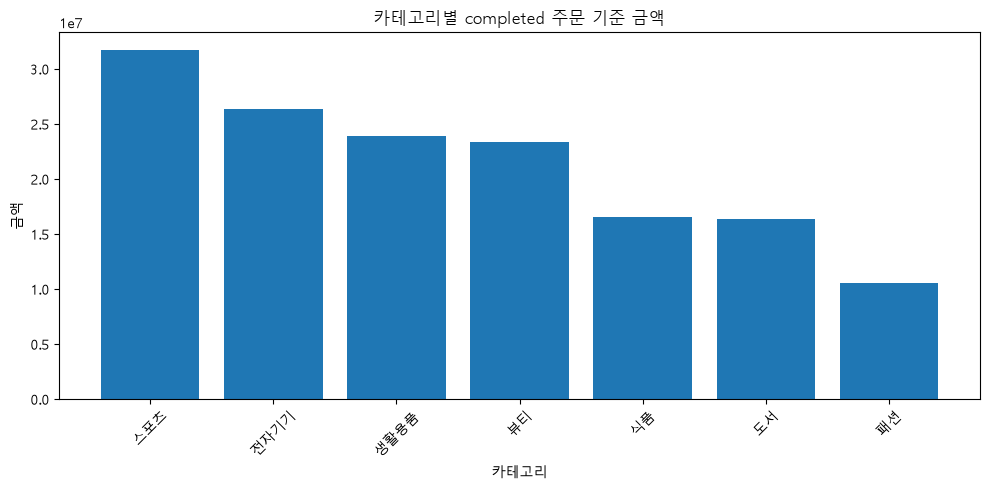

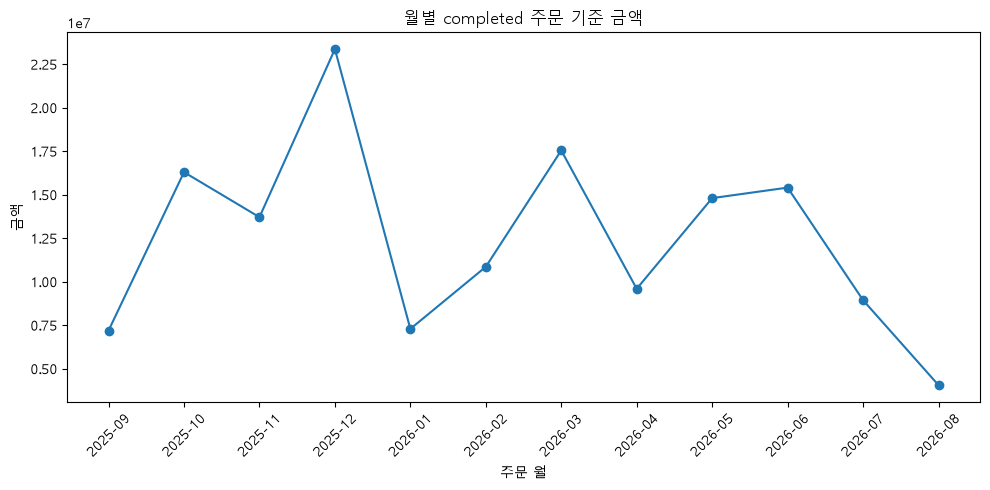

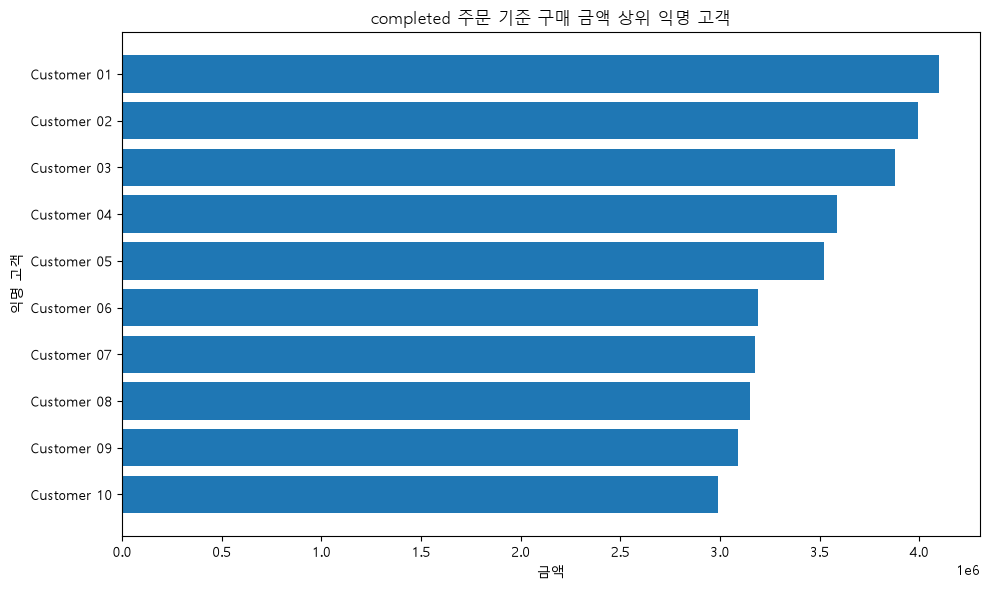

ch08_category_sales.png True 28333
ch08_monthly_sales.png True 79251
ch08_top_customers.png True 47302


In [55]:
saved_figures = create_project_figures(
    analysis_tables,
    FIGURE_DIR,
    show=True,
)

for path in saved_figures:
    print(path.name, path.exists(), path.stat().st_size)

## 6. 대표 시각화

![대표 그래프 1](images/graph01.png)
![대표 그래프 2](images/graph02.png)
![대표 그래프 3](images/graph03.png)

### 그래프 선택 이유

카테고리별 그래프는 completed 주문 금액이 어떤 카테고리에 많이 분포하는지 비교하기 위해 선택했다.

월별 그래프는 completed 주문 금액이 시간에 따라 어떻게 변하는지 확인하기 위해 선택했다.

상위 익명 고객 그래프는 completed 주문 기준 구매 금액이 높은 고객들을 비교하기 위해 선택했다.

### 그래프와 원본 집계값 일치 여부

세 그래프 모두 앞서 검증된 집계 결과를 사용해 생성했으며,
원본 집계값과 일치한다.

### 그래프에서 직접 관찰한 사실

카테고리별 completed 주문 기준 금액은 스포츠가 가장 높고 패션이 가장 낮았다.

월별 completed 주문 기준 금액은 2025년 12월이 가장 높고,
2026년 8월이 가장 낮았다.

고객별 completed 주문 기준 구매 금액은 Customer 01이 가장 높았고,
상위 고객 사이에서도 구매 금액 차이가 존재했다.

### 그래프만으로 말할 수 없는 것

그래프만으로 금액 차이의 원인을 알 수는 없다.
광고, 프로모션, 계절성, 고객 선호도, 수익성 등의 정보는 현재 데이터에 포함되어 있지 않으므로
이러한 요인을 원인으로 단정할 수 없다.

In [56]:
report_text = build_midterm_report(
    dataset_summary,
    preprocessing_comparison,
    key_duplicate_checks,
    relationship_checks,
    analysis_tables,
    interpretation_notes,
)

report_path = REPORT_DIR / "ch08_midterm_report.md"
report_path.write_text(report_text, encoding="utf-8")

print("보고서 저장:", report_path)
print(report_text[:1800])

보고서 저장: c:\dev\llm-data-analysis-study\reports\ch08_midterm_report.md
# Chapter 8 중간 프로젝트 보고서

## 1. 분석 목적

온라인 쇼핑몰 데이터를 사용해 completed 주문 기준 금액과 고객 구매 패턴을 분석했습니다.

## 2. 분석 기준

- 금액성 분석은 `order_status == "completed"`인 주문만 포함했습니다.
- `line_total = quantity × unit_price` 관계를 검증했습니다.
- 취소·환불 등 non-completed 주문을 포함한 금액은 전체 주문 상세 금액으로 구분했습니다.
- 공개 고객 결과에서는 이름·연락처·원본 고객 ID를 제외하고 순위 기반 익명 라벨을 사용했습니다.
- 병합은 관계 검증, `validate`, 행 수, 미매칭을 확인했습니다.
- 같은 completed 범위의 카테고리·월·고객 총합을 source total과 대조했습니다.

## 3. 데이터 개요

```text
    dataset  rows  columns  missing_values  duplicated_rows
  customers   150        6               0                0
   products   100        4               0                0
     orders   300        5               0                0
order_items   764        5               0                0
```

## 4. 전처리 전후 비교

```text
    dataset  rows_raw  columns_raw  rows_processed  columns_processed
  customers       150            6             150                  6
order_items  

## 9. LLM 활용 기록

- 사용 여부: 사용
- 사용 목적:
  - Chapter 08 과제 진행 순서 확인
  - 각 검증 결과의 의미 이해
  - Notebook Markdown 답안 문장 정리
  - 과도한 해석 여부 점검

- Safe Context:
  - 분석 질문
  - 데이터 shape와 컬럼 구조
  - PK/FK 검증 결과
  - 병합 검증 결과
  - completed 주문 기준 집계 결과
  - total consistency 결과
  - 개인정보 제거 여부
  - 최종 Validation 결과

- Prompt 요약:
  - 각 단계의 실행 결과를 바탕으로 무엇을 확인해야 하는지 질문했다.
  - 결과값을 과제 답안 양식에 어떻게 정리하면 되는지 도움을 요청했다.
  - 데이터에 없는 원인을 과도하게 해석하지 않도록 문장을 검토했다.

- 제안 요약:
  - PK/FK, 병합, line_total, total consistency 결과를 각각 근거와 함께 작성하도록 제안받았다.
  - 카테고리, 월별, 고객별 결과는 관찰과 원인 추정을 구분해 작성하도록 제안받았다.
  - 개인정보와 재현성 검증 결과를 별도로 기록하도록 제안받았다.

- 반영/수정/보류:
  - 실제 Notebook 출력값과 일치하는 내용만 반영했다.
  - 광고, 프로모션, 계절성, 고객 선호도처럼 데이터에 근거가 없는 원인 해석은 반영하지 않았다.
  - 최종 문장은 실제 수치와 Validation 결과를 다시 확인한 뒤 수정했다.

- 사람이 검증한 근거:
  - PK/FK Gate: PASS
  - 병합 / line_total Gate: PASS
  - completed/category/monthly/customer 총합: 148,990,000원으로 일치
  - Privacy Gate: PASS
  - Project Validation: 전체 PASS
  - 전체 프로젝트 재실행 후 동일 결과 확인

In [57]:
project_result = run_midterm_project(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    report_dir=REPORT_DIR,
    figure_dir=FIGURE_DIR,
    show_figures=False,
)

display(project_result["project_validation"])
project_result["report_path"]

,check,value,expected,status
0,pk_integrity,all PASS,all PASS,PASS
1,fk_integrity,0,0,PASS
2,merge_checks_pass,all PASS,all PASS,PASS
3,line_total_consistency,0,0,PASS
4,completed_total_consistency,all match,all match,PASS
5,category_sales_ratio_pct_sum,100.0,100.0,PASS
6,completed_rows_with_invalid_order_date,0,0,PASS
7,public_customer_columns_safe,no forbidden columns,no forbidden columns,PASS


WindowsPath('c:/dev/llm-data-analysis-study/reports/ch08_midterm_report.md')

## 10. 프로젝트 재현 확인

- `python scripts/run_midterm_project.py` 실행 여부: 실행 완료
- 재실행 결과: 정상 완료
- Notebook과 핵심 수치 일치 여부: 일치
- 생성된 핵심 Evidence 파일 확인 여부: 확인 완료

![재실행 결과](images/step06_reproduce.png)

### 나의 해석과 판단

전체 프로젝트를 다시 실행한 결과 PK/FK, 병합, line_total, total consistency,
날짜, 개인정보 관련 Validation이 모두 PASS로 확인되었다.
또한 Notebook에서 확인한 completed 기준 총금액 148,990,000원과
전체 재실행 결과의 핵심 수치가 일치했다.
재실행 가능한 프로젝트는 이전 셀의 메모리 상태나 실행 순서에 의존하지 않고
같은 입력 데이터에서 같은 결과를 다시 얻을 수 있다는 점에서 중요하다고 판단했다.

In [58]:
expected_outputs = [
    REPORT_DIR / "ch08_midterm_report.md",
    REPORT_DIR / "ch08_dataset_summary.csv",
    REPORT_DIR / "ch08_preprocessing_comparison.csv",
    REPORT_DIR / "ch08_key_duplicate_checks.csv",
    REPORT_DIR / "ch08_relationship_checks.csv",
    REPORT_DIR / "ch08_merge_checks.csv",
    REPORT_DIR / "ch08_line_total_check.csv",
    REPORT_DIR / "ch08_date_checks.csv",
    REPORT_DIR / "ch08_amount_scope_summary.csv",
    REPORT_DIR / "ch08_total_consistency_check.csv",
    REPORT_DIR / "ch08_project_validation.csv",
    REPORT_DIR / "ch08_category_sales.csv",
    REPORT_DIR / "ch08_monthly_sales.csv",
    REPORT_DIR / "ch08_customer_sales.csv",
    REPORT_DIR / "ch08_order_status_summary.csv",
    REPORT_DIR / "ch08_interpretation_notes.csv",
    FIGURE_DIR / "ch08_category_sales.png",
    FIGURE_DIR / "ch08_monthly_sales.png",
    FIGURE_DIR / "ch08_top_customers.png",
]

all_outputs_valid = True
for path in expected_outputs:
    valid = path.exists() and path.stat().st_size > 0
    all_outputs_valid &= valid
    print(path.name, "OK" if valid else "MISSING OR EMPTY")

assert all_outputs_valid
print("전체 산출물 검증: PASS")

ch08_midterm_report.md OK
ch08_dataset_summary.csv OK
ch08_preprocessing_comparison.csv OK
ch08_key_duplicate_checks.csv OK
ch08_relationship_checks.csv OK
ch08_merge_checks.csv OK
ch08_line_total_check.csv OK
ch08_date_checks.csv OK
ch08_amount_scope_summary.csv OK
ch08_total_consistency_check.csv OK
ch08_project_validation.csv OK
ch08_category_sales.csv OK
ch08_monthly_sales.csv OK
ch08_customer_sales.csv OK
ch08_order_status_summary.csv OK
ch08_interpretation_notes.csv OK
ch08_category_sales.png OK
ch08_monthly_sales.png OK
ch08_top_customers.png OK
전체 산출물 검증: PASS


In [59]:
# 실습 과제 코드를 아래에 작성하세요.